In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
print("Imports successful ✓")

Imports successful ✓


In [2]:
X_train = pd.read_csv('../outputs/X_train.csv')
X_val = pd.read_csv('../outputs/X_val.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_val = pd.read_csv('../outputs/y_val.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("y_train default rate:", round(y_train.mean() * 100, 1), "%")

X_train shape: (246008, 201)
X_val shape:   (61503, 201)
y_train default rate: 8.1 %


In [3]:
# Clean column names - replace special characters with underscore
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

print("Column names cleaned ✓")

Column names cleaned ✓


In [4]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_val)
lr_proba = lr_model.predict_proba(X_val)[:, 1]

print("Logistic Regression trained ✓")

Logistic Regression trained ✓


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest trained ✓")

Random Forest trained ✓


In [6]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           scale_pos_weight=11, eval_metric='auc')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_val)
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost trained ✓")

XGBoost trained ✓


In [7]:
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42,
                             scale_pos_weight=11)
lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_val)
lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]

print("LightGBM trained ✓")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6204
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 190
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LightGBM trained ✓


In [8]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

all_preds = [lr_preds, rf_preds, xgb_preds, lgbm_preds]
all_proba = [lr_proba, rf_proba, xgb_proba, lgbm_proba]

results = []

for i in range(len(models)):
    auc   = roc_auc_score(y_val, all_proba[i])
    f1    = f1_score(y_val, all_preds[i])
    prec  = precision_score(y_val, all_preds[i])
    rec   = recall_score(y_val, all_preds[i])

    results.append({
        'Model':     models[i],
        'AUC-ROC':   round(auc, 4),
        'F1 Score':  round(f1, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  AUC-ROC  F1 Score  Precision  Recall
0  Logistic Regression   0.6119    0.1876     0.1148  0.5132
1        Random Forest   0.7247    0.0032     0.8000  0.0016
2              XGBoost   0.7458    0.2738     0.1772  0.6020
3             LightGBM   0.7593    0.2714     0.1702  0.6701


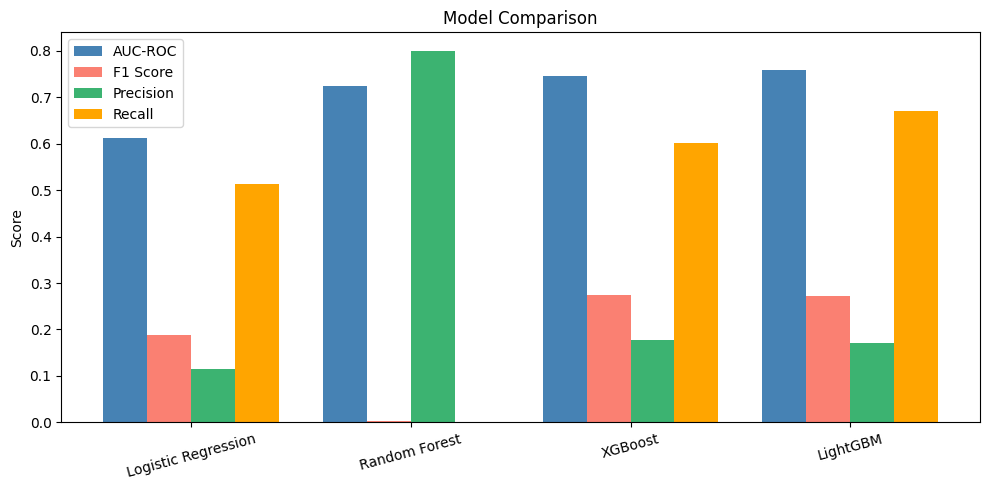

In [9]:
plt.figure(figsize=(10, 5))

x = np.arange(len(models))
width = 0.2

plt.bar(x - 0.3, results_df['AUC-ROC'],  width, label='AUC-ROC',   color='steelblue')
plt.bar(x - 0.1, results_df['F1 Score'], width, label='F1 Score',  color='salmon')
plt.bar(x + 0.1, results_df['Precision'],width, label='Precision', color='mediumseagreen')
plt.bar(x + 0.3, results_df['Recall'],   width, label='Recall',    color='orange')

plt.xticks(x, models, rotation=15)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

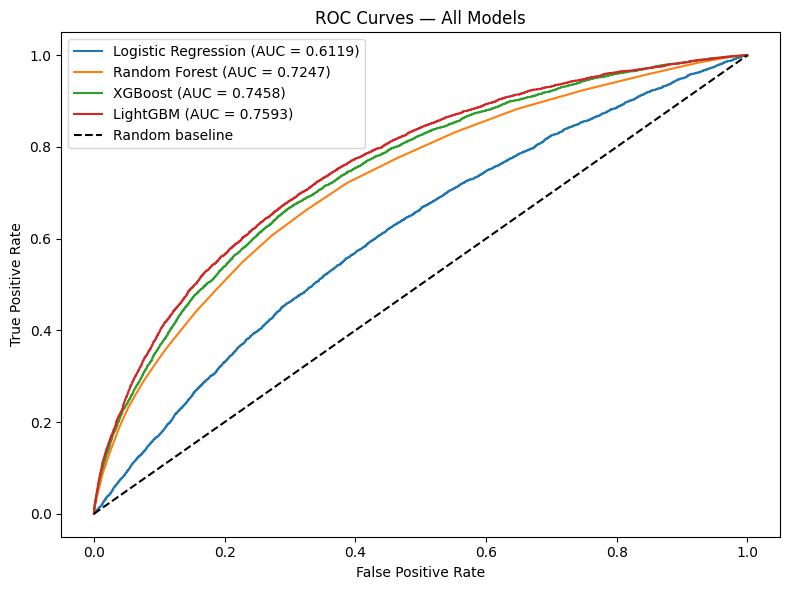

In [10]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for i in range(len(models)):
    fpr, tpr, _ = roc_curve(y_val, all_proba[i])
    auc = results_df['AUC-ROC'][i]
    plt.plot(fpr, tpr, label=models[i] + ' (AUC = ' + str(auc) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png')
plt.show()

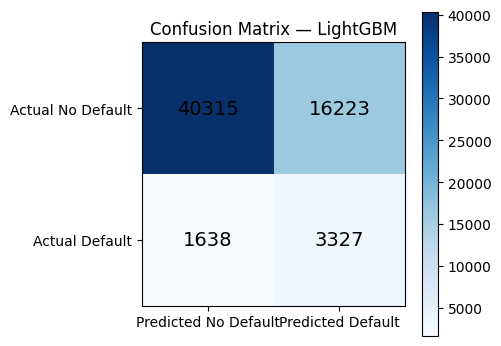

In [11]:
cm = confusion_matrix(y_val, lgbm_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — LightGBM')
plt.colorbar()

plt.xticks([0, 1], ['Predicted No Default', 'Predicted Default'])
plt.yticks([0, 1], ['Actual No Default', 'Actual Default'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

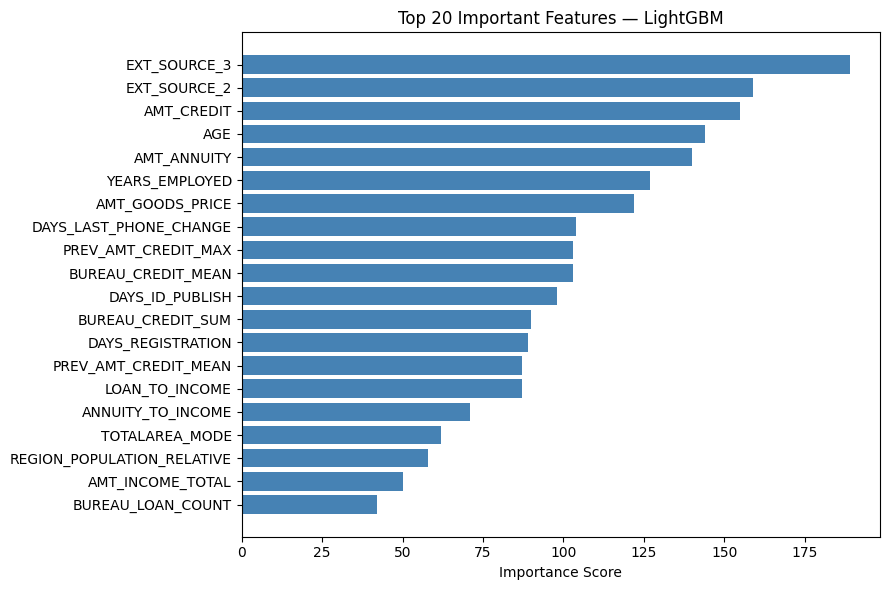

In [16]:
importance = lgbm_model.feature_importances_
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values('Importance', ascending=False)
top20 = importance_df.head(20)

plt.figure(figsize=(9, 6))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
plt.title('Top 20 Important Features — LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [18]:
os.makedirs('../models', exist_ok=True)

joblib.dump(lgbm_model, '../models/lgbm_model.pkl')

print("Model saved ✓")
print("Location: models/lgbm_model.pkl")


Model saved ✓
Location: models/lgbm_model.pkl
